# Step 2: Data Cleaning, Feature Engineering, and EDA

## Overview
This notebook continues the streaming platform content strategy project. In Step 1, TV show data was collected from the TVMaze API and converted into structured CSV files.

In this step, the focus is on:
- Inspecting the dataset
- Cleaning missing, duplicate, and inconsistent values
- Creating useful new features
- Performing exploratory data analysis
- Identifying initial patterns and insights
- Evaluating possible bias and fairness issues in the dataset

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Loading the Dataset

The structured dataset from Step 1 will be used as the starting point for cleaning and analysis. This file contains selected and extracted columns from the original TVMaze API response.

In [245]:
df = pd.read_csv("data/raw/shows_structured.csv")

df.head()

,show_id,name,type,language,genres,status,runtime,average_runtime,premiered,ended,official_site,rating_average,network_name,country_name,country_code,summary
0,1,Under the Dome,Scripted,English,"Drama, Science-Fiction, Thriller",Ended,60.0,60.0,2013-06-24,2015-09-10,http://www.cbs.com/shows/under-the-dome/,6.6,CBS,United States,US,<p><b>Under the Dome</b> is the story of a sma...
1,2,Person of Interest,Scripted,English,"Action, Crime, Science-Fiction",Ended,60.0,60.0,2011-09-22,2016-06-21,http://www.cbs.com/shows/person_of_interest/,8.8,CBS,United States,US,<p>You are being watched. The government has a...
2,3,Bitten,Scripted,English,"Drama, Horror, Romance",Ended,60.0,60.0,2014-01-11,2016-04-15,http://bitten.space.ca/,7.4,CTV Sci-Fi Channel,Canada,CA,<p>Based on the critically acclaimed series of...
3,4,Arrow,Scripted,English,"Drama, Action, Science-Fiction",Ended,60.0,60.0,2012-10-10,2020-01-28,NaN,7.4,The CW,United States,US,"<p>After a violent shipwreck, billionaire play..."
4,5,True Detective,Scripted,English,"Drama, Crime, Thriller",Running,60.0,63.0,2014-01-12,NaN,https://www.max.com/shows/true-detective/9a4a3...,8.1,HBO,United States,US,<p>Touch darkness and darkness touches you bac...


In [246]:
print("Dataset shape:")
print(df.shape)

Dataset shape:
(727, 16)


## 2. Initial Data Inspection

In this section, I will inspect the dataset structure, data types, missing values, duplicate records, and basic summaries before starting the cleaning process.

In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 727 entries, 0 to 726
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   show_id          727 non-null    int64  
 1   name             727 non-null    object 
 2   type             727 non-null    object 
 3   language         727 non-null    object 
 4   genres           669 non-null    object 
 5   status           727 non-null    object 
 6   runtime          680 non-null    float64
 7   average_runtime  726 non-null    float64
 8   premiered        726 non-null    object 
 9   ended            653 non-null    object 
 10  official_site    423 non-null    object 
 11  rating_average   663 non-null    float64
 12  network_name     688 non-null    object 
 13  country_name     688 non-null    object 
 14  country_code     688 non-null    object 
 15  summary          727 non-null    object 
dtypes: float64(3), int64(1), object(12)
memory usage: 91.0+ KB


In [248]:
# Check missing values count and percentage for each column
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": missing_percentage.round(2)
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary

,missing_count,missing_percentage
genres,58,7.98
runtime,47,6.46
average_runtime,1,0.14
premiered,1,0.14
ended,74,10.18
official_site,304,41.82
rating_average,64,8.80
network_name,39,5.36
country_name,39,5.36
country_code,39,5.36


In [249]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Statistical Summary

In this step, I will review summary statistics for both numerical and categorical columns. This helps understand the range, distribution, and most common values in the dataset.

In [250]:
# Summary statistics for numerical columns
df.describe()

,show_id,runtime,average_runtime,rating_average
count,727.000000,680.000000,726.000000,663.000000
mean,375.079780,51.201471,50.714876,7.486727
std,215.421227,18.008483,17.632727,0.813225
min,1.000000,10.000000,8.000000,3.200000
25%,190.500000,30.000000,30.000000,7.100000
50%,374.000000,60.000000,60.000000,7.700000
75%,559.500000,60.000000,60.000000,8.000000
max,749.000000,120.000000,120.000000,9.200000


In [251]:
# Summary statistics for categorical columns
df.describe(include="object")

,name,type,language,genres,status,premiered,ended,official_site,network_name,country_name,country_code,summary
count,727,727,727,669,727,726,653,423,688,688,688,727
unique,720,10,2,180,3,625,590,422,96,7,7,727
top,Charlie's Angels,Scripted,English,Comedy,Ended,2014-10-28,2014-12-18,http://www.tv-tokyo.co.jp/anime/naruto/index2....,NBC,United States,US,<p><b>Under the Dome</b> is the story of a sma...
freq,2,537,719,89,654,5,6,2,66,600,600,1


### Statistical Summary Findings

The numerical summary helps identify the range of values for runtime, average runtime, and rating. The categorical summary helps identify common values in columns such as type, language, status, network, and country.

These summaries will support the cleaning and EDA steps by showing which columns are useful for analysis and which columns may need transformation.

### Initial Inspection Findings

The dataset contains 727 rows and 16 columns. No duplicate rows were found.

Several columns contain missing values. Some missing values are expected because not all TV shows have an official website, end date, rating, network, or country information. For example, running shows may not have an ended date, and some shows may not have rating information available.

The missing values will be handled based on the meaning of each column instead of applying one method to all columns.

## 3. Data Cleaning Plan

Based on the initial inspection, the following cleaning steps will be applied:

- Remove duplicate rows if any exist.
- Convert date columns such as `premiered` and `ended` into datetime format.
- Fill missing categorical values such as `genres`, `network_name`, `country_name`, and `country_code` with `Unknown`.
- Keep missing `ended` values as null after converting the column to datetime, because missing end dates may indicate that the show is still running.
- Handle missing numerical values such as `runtime`, `average_runtime`, and `rating_average` using appropriate replacement values.
- Keep columns that are useful for analysis and document any columns that are not used in the final cleaned dataset.

### Irrelevant and Inconsistent Features Review

During the cleaning process, the dataset columns were reviewed to decide which features are useful for analysis. Columns that support content strategy analysis, such as `type`, `language`, `genres`, `runtime`, `rating_average`, `network_name`, `premiered`, and `summary`, were kept.

Nested or unclear fields from the original API response were already simplified in Step 1. In Step 2, the focus was on using the structured dataset and improving it through cleaning and feature engineering.

Some fields had inconsistent completeness, such as missing ratings, network information, official websites, and end dates. These were handled based on the meaning of each column instead of applying one cleaning method to all features.

## 4. Data Cleaning

In this section, I will create a copy of the original dataset and apply the cleaning steps. The raw dataset will remain unchanged, while the cleaned version will be saved as a new CSV file.

In [252]:
# Create a copy of the dataset for cleaning
df_cleaned = df.copy()

# Remove duplicate rows
df_cleaned = df_cleaned.drop_duplicates()

# Convert date columns to datetime format
df_cleaned["premiered"] = pd.to_datetime(df_cleaned["premiered"], errors="coerce")
df_cleaned["ended"] = pd.to_datetime(df_cleaned["ended"], errors="coerce")

# Remove rows with missing premiere date because it is needed for time-based analysis
df_cleaned = df_cleaned.dropna(subset=["premiered"])

# Fill missing categorical values
categorical_columns = ["genres", "network_name", "country_name", "country_code"]

for column in categorical_columns:
    df_cleaned[column] = df_cleaned[column].fillna("Unknown")

# Fill missing official site values
df_cleaned["official_site"] = df_cleaned["official_site"].fillna("Not Available")

# Fill missing numerical values using median
numerical_columns = ["runtime", "average_runtime", "rating_average"]

for column in numerical_columns:
    df_cleaned[column] = df_cleaned[column].fillna(df_cleaned[column].median())

# Check the cleaned dataset
print("Cleaned dataset shape:", df_cleaned.shape)
df_cleaned.head()

Cleaned dataset shape: (726, 16)


,show_id,name,type,language,genres,status,runtime,average_runtime,premiered,ended,official_site,rating_average,network_name,country_name,country_code,summary
0,1,Under the Dome,Scripted,English,"Drama, Science-Fiction, Thriller",Ended,60.0,60.0,2013-06-24,2015-09-10,http://www.cbs.com/shows/under-the-dome/,6.6,CBS,United States,US,<p><b>Under the Dome</b> is the story of a sma...
1,2,Person of Interest,Scripted,English,"Action, Crime, Science-Fiction",Ended,60.0,60.0,2011-09-22,2016-06-21,http://www.cbs.com/shows/person_of_interest/,8.8,CBS,United States,US,<p>You are being watched. The government has a...
2,3,Bitten,Scripted,English,"Drama, Horror, Romance",Ended,60.0,60.0,2014-01-11,2016-04-15,http://bitten.space.ca/,7.4,CTV Sci-Fi Channel,Canada,CA,<p>Based on the critically acclaimed series of...
3,4,Arrow,Scripted,English,"Drama, Action, Science-Fiction",Ended,60.0,60.0,2012-10-10,2020-01-28,Not Available,7.4,The CW,United States,US,"<p>After a violent shipwreck, billionaire play..."
4,5,True Detective,Scripted,English,"Drama, Crime, Thriller",Running,60.0,63.0,2014-01-12,NaT,https://www.max.com/shows/true-detective/9a4a3...,8.1,HBO,United States,US,<p>Touch darkness and darkness touches you bac...


### Cleaning Verification

After applying the cleaning steps, I will check the dataset again to make sure duplicates were removed, missing values were handled correctly, and date columns were converted successfully.

In [253]:
# Check missing values after cleaning
cleaned_missing_values = df_cleaned.isnull().sum()

cleaned_missing_summary = pd.DataFrame({
    "missing_count": cleaned_missing_values
})

cleaned_missing_summary = cleaned_missing_summary[cleaned_missing_summary["missing_count"] > 0]
cleaned_missing_summary

,missing_count
ended,73


In [254]:
# Check duplicates after cleaning
print("Number of duplicate rows after cleaning:", df_cleaned.duplicated().sum())

Number of duplicate rows after cleaning: 0


In [255]:
# Check data types after cleaning
df_cleaned.dtypes

show_id                     int64
name                       object
type                       object
language                   object
genres                     object
status                     object
runtime                   float64
average_runtime           float64
premiered          datetime64[ns]
ended              datetime64[ns]
official_site              object
rating_average            float64
network_name               object
country_name               object
country_code               object
summary                    object
dtype: object

### Cleaning Results

After cleaning the dataset, duplicate rows were checked and no duplicate records were found. Missing categorical values were filled with `Unknown`, missing official website values were filled with `Not Available`, and missing numerical values were filled using the median.

The `premiered` column was converted to datetime format, and rows with missing premiere dates were removed because this column is needed for time-based analysis. Missing values in the `ended` column were kept as null because they may indicate that the show is still running.

## 5. Feature Engineering

In this section, I will create new features from the existing columns to support deeper analysis. These features will help analyze release trends, show status, genre diversity, and text information from show summaries.

### Feature Engineering Documentation

| Technique | What was done | Why it was necessary | How it was implemented |
|---|---|---|---|
| Date-based features | Created `premiere_year` and `premiere_month` | To analyze release trends over time | Extracted year and month from the `premiered` datetime column |
| Derived metrics | Created `show_age` and `genre_count` | To measure how old each show is and how diverse its genres are | Calculated show age using the premiere year and counted genres by splitting the genre list |
| Rating classification | Created `rating_category` | To group shows into easier rating levels for analysis | Used rating ranges to classify shows as Low, Medium, or High |
| Text-based features | Created `summary_word_count` and `summary_character_count` | To convert summary text into numerical features | Cleaned the summary text and counted words and characters |
| Sentiment analysis | Created `sentiment_score` and `sentiment_label` | To capture the general tone of each show summary | Used TextBlob to calculate sentiment polarity and assign sentiment labels |
| Clustering | Created `content_cluster` | To group shows into content segments based on numerical patterns | Standardized selected numerical features and applied KMeans clustering |
| External API enrichment | Created `episode_count` and `episode_count_category` | To add content volume information that was not available in the original show-level dataset | Requested the TVMaze Episodes API for each show ID and counted the number of returned episodes |

### Standardization for Clustering

Numerical features used for KMeans clustering were standardized using `StandardScaler`. This was necessary because KMeans is distance-based, and features with larger numeric ranges could have a stronger effect on the clustering result.

Standardization helps make sure each numerical feature contributes more equally to the clustering process.

In [256]:
%pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [257]:
import re
from textblob import TextBlob
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#  Date-based features 
df_cleaned["premiere_year"] = df_cleaned["premiered"].dt.year
df_cleaned["premiere_month"] = df_cleaned["premiered"].dt.month

# Create a feature to identify whether a show has ended
df_cleaned["is_ended"] = df_cleaned["ended"].notnull()

# Create a feature for show age based on premiere year
current_year = 2026
df_cleaned["show_age"] = current_year - df_cleaned["premiere_year"]

#  Genre features
df_cleaned["genre_count"] = df_cleaned["genres"].apply(
    lambda x: 0 if x == "Unknown" else len(str(x).split(","))
)

#  Text cleaning & counting features 
df_cleaned["summary"] = df_cleaned["summary"].fillna("")
df_cleaned["summary_clean"] = df_cleaned["summary"].apply(
    lambda x: re.sub("<.*?>", "", str(x))
)

df_cleaned["summary_word_count"] = df_cleaned["summary_clean"].apply(
    lambda x: len(str(x).split())
)

df_cleaned["summary_character_count"] = df_cleaned["summary_clean"].apply(
    lambda x: len(str(x))
)

df_cleaned["summary"] = df_cleaned["summary_clean"]
df_cleaned = df_cleaned.drop(columns=["summary_clean"])



### Language and Readability Features

In this step, I created simple readability-related features from the cleaned `summary` text. These features help describe the structure and complexity of each show summary.

The created features include sentence count, average sentence length, and average word length. These features can support text-based analysis by showing whether summaries are short, long, simple, or more detailed.

In [258]:

def count_sentences(text):
    text = str(text)
    sentences = re.split(r"[.!?]+", text)
    sentences = [sentence.strip() for sentence in sentences if sentence.strip()]
    return len(sentences)

def average_sentence_length(text):
    text = str(text)
    sentences = re.split(r"[.!?]+", text)
    sentences = [sentence.strip() for sentence in sentences if sentence.strip()]
    
    if len(sentences) == 0:
        return 0
    
    word_counts = [len(sentence.split()) for sentence in sentences]
    return round(sum(word_counts) / len(word_counts), 2)

def average_word_length(text):
    text = str(text)
    words = re.findall(r"\b[a-zA-Z]+\b", text)
    
    if len(words) == 0:
        return 0
    
    word_lengths = [len(word) for word in words]
    return round(sum(word_lengths) / len(word_lengths), 2)

df_cleaned["sentence_count"] = df_cleaned["summary"].apply(count_sentences)
df_cleaned["average_sentence_length"] = df_cleaned["summary"].apply(average_sentence_length)
df_cleaned["average_word_length"] = df_cleaned["summary"].apply(average_word_length)

df_cleaned[
    [
        "name",
        "sentence_count",
        "average_sentence_length",
        "average_word_length"
    ]
].head()

,name,sentence_count,average_sentence_length,average_word_length
0,Under the Dome,2,28.50,4.46
1,Person of Interest,13,7.38,4.38
2,Bitten,4,18.75,4.64
3,Arrow,3,28.33,5.08
4,True Detective,4,12.00,5.06


### Language and Readability Features Result

Three new readability-related features were created: `sentence_count`, `average_sentence_length`, and `average_word_length`.

These features provide simple information about the length and structure of each show summary and can be useful for future text analysis or content description comparisons.

### Keyword Extraction from Summary

To add another text-based feature, I extracted simple keywords from the cleaned `summary` column. This helps identify important terms that appear in each show summary and converts text into more useful information for analysis.

A simple keyword extraction approach was used by removing common stop words and selecting the most frequent meaningful words from each summary.

In [259]:

# Define a simple list of common stop words
stop_words = {
    "the", "and", "or", "a", "an", "to", "of", "in", "on", "for", "with",
    "is", "are", "was", "were", "by", "as", "at", "from", "that", "this",
    "it", "its", "into", "about", "their", "his", "her", "they", "them",
    "he", "she", "who", "what", "when", "where", "which", "will", "be",
    "has", "have", "had", "but", "not", "can", "more", "than", "one",
    "two", "new", "life", "world"
}

def extract_keywords(text, top_n=5):
    text = str(text).lower()
    words = re.findall(r"\b[a-zA-Z]{4,}\b", text)
    words = [word for word in words if word not in stop_words]

    word_counts = pd.Series(words).value_counts()

    if word_counts.empty:
        return "No Keywords"

    return ", ".join(word_counts.head(top_n).index)

# Extract top keywords from each show summary
df_cleaned["summary_keywords"] = df_cleaned["summary"].apply(extract_keywords)

df_cleaned[["name", "summary_keywords"]].head()

,name,summary_keywords
0,Under the Dome,"dome, town, under, deal, came"
1,Person of Interest,"government, secret, people, machine, every"
2,Bitten,"elena, based, changed, found, happily"
3,Arrow,"former, oliver, lance, after, skills"
4,True Detective,"true, detective, darkness, touch, cast"


### Keyword Extraction Result

A new feature called `summary_keywords` was created from the cleaned summary text. This feature stores the most frequent meaningful words from each show summary after removing common stop words.

This feature can help identify important themes in show descriptions and can support future content analysis.

### Sentiment Analysis

In this step, I used TextBlob to calculate the sentiment polarity of each cleaned show summary. The sentiment score ranges from -1 to +1, where negative values indicate negative sentiment, positive values indicate positive sentiment, and values close to 0 indicate neutral sentiment.

A new feature called `sentiment_label` was created to classify each summary as Positive, Neutral, or Negative based on the sentiment score.

In [260]:

# Sentiment polarity score: ranges from -1 (very negative) to +1 (very positive)
df_cleaned["sentiment_score"] = df_cleaned["summary"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity if str(x).strip() != "" else 0
)

# Sentiment label based on score thresholds
df_cleaned["sentiment_label"] = df_cleaned["sentiment_score"].apply(
    lambda x: "Positive" if x > 0.05 else ("Negative" if x < -0.05 else "Neutral")
)

print("Sentiment label distribution:")
print(df_cleaned["sentiment_label"].value_counts())



Sentiment label distribution:
sentiment_label
Positive    432
Neutral     167
Negative    127
Name: count, dtype: int64


### Sentiment Analysis Result

The sentiment analysis created two new features: `sentiment_score` and `sentiment_label`. These features help convert summary text into numerical and categorical information that can be used for analysis.

### Topic Modeling from Summary

To apply topic modeling, I used the cleaned `summary` text to identify general themes in the show descriptions. Since the summaries are short, this step is used as an exploratory text-based feature engineering technique.

The goal is to create a new feature called `summary_topic`, which assigns each show to a general topic based on the words used in its summary.

In [261]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# Prepare text data from the cleaned summary column
summary_text = df_cleaned["summary"].fillna("")

# Convert summaries into TF-IDF features
tfidf_vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(summary_text)

# Apply topic modeling using NMF
num_topics = 5

nmf_model = NMF(
    n_components=num_topics,
    random_state=42,
    max_iter=500
)

topic_matrix = nmf_model.fit_transform(tfidf_matrix)

# Assign the most relevant topic to each show
df_cleaned["summary_topic"] = topic_matrix.argmax(axis=1)

# Display top words for each topic
feature_names = tfidf_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [
        feature_names[i]
        for i in topic.argsort()[-10:][::-1]
    ]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")

# Preview the new topic feature
df_cleaned[["name", "summary_topic"]].head()

Topic 0: family, son, year, wife, father, life, american, old, home, business
Topic 1: series, comedy, based, drama, television, american, set, lives, hit, stars
Topic 2: team, police, detective, crime, drama, crimes, solve, criminal, dr, unit
Topic 3: world, years, time, war, earth, mysterious, people, battle, future, story
Topic 4: new, life, city, york, love, women, friends, follows, young, best


,name,summary_topic
0,Under the Dome,3
1,Person of Interest,2
2,Bitten,4
3,Arrow,2
4,True Detective,2


### Topic Modeling Result

A new feature called `summary_topic` was created using topic modeling on the cleaned show summaries. Each show was assigned to one topic based on the words in its summary.

This feature can help group shows by general themes and may support future content recommendation or categorization analysis.

### Rating Category

In this step, I created a new categorical feature called `rating_category`. This feature groups shows into Low, Medium, and High categories based on their average rating.

This makes rating values easier to compare and supports later analysis of show quality levels.

In [262]:
# Rating category
df_cleaned["rating_category"] = pd.cut(
    df_cleaned["rating_average"],
    bins=[0, 5, 7, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

### Rating Category Result

The `rating_category` feature was created successfully. It allows the dataset to compare shows using rating groups instead of only numerical rating values.

### KMeans Clustering and Standardization

In this step, I used KMeans clustering to group shows into 3 content clusters based on numerical features such as `rating_average` and `runtime`.

Before applying KMeans, the numerical features were standardized using `StandardScaler`. This was necessary because KMeans is distance-based, and features with larger numeric ranges could have a stronger effect on the clustering result.

The new feature `content_cluster` was created to represent the cluster assigned to each show.

In [263]:
# KMeans Clustering 
# Group shows into 3 content clusters based on rating and runtime
cluster_features = df_cleaned[["rating_average", "runtime"]].copy()
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cleaned["content_cluster"] = kmeans.fit_predict(cluster_scaled)

print("\nContent cluster distribution:")
print(df_cleaned["content_cluster"].value_counts().sort_index())


Content cluster distribution:
content_cluster
0    205
1    101
2    420
Name: count, dtype: int64


c:\Users\halswaidan.t\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


### KMeans Clustering Result

The `content_cluster` feature was created successfully using KMeans clustering. This feature groups shows into content segments based on similarities in rating and runtime.

These clusters can support future content strategy analysis by identifying groups of shows with similar numerical patterns.

### 5.1 External Data Integration

**What was done:**  
Episode count data was collected from the TVMaze Episodes API for each show and added as a new feature called `episode_count`.

**Why it was necessary:**  
The original show-level dataset did not include episode count information. Adding this feature allows the analysis to consider show length and content volume, which can support content strategy decisions.

**How it was implemented:**  
A loop was used to request the TVMaze Episodes API for each `show_id`. The number of episodes returned by the API was counted and stored in the `episode_count` column. A second feature, `episode_count_category`, was created to group shows into Short, Medium, Long, and Very Long categories.

In [264]:
import requests
import time

episode_counts = []

for index, show_id in enumerate(df_cleaned["show_id"], start=1):
    episodes_url = f"https://api.tvmaze.com/shows/{show_id}/episodes"

    try:
        response = requests.get(episodes_url, timeout=10)

        if response.status_code == 200:
            episodes = response.json()
            episode_counts.append(len(episodes))
        else:
            episode_counts.append(0)

    except requests.exceptions.RequestException:
        episode_counts.append(0)

    if index % 50 == 0:
        print(f"Processed {index} shows...")

df_cleaned["episode_count"] = episode_counts

df_cleaned[["show_id", "name", "episode_count"]].head()

Processed 50 shows...
Processed 100 shows...
Processed 150 shows...
Processed 200 shows...
Processed 250 shows...
Processed 300 shows...
Processed 350 shows...
Processed 400 shows...
Processed 450 shows...
Processed 500 shows...
Processed 550 shows...
Processed 600 shows...
Processed 650 shows...
Processed 700 shows...


,show_id,name,episode_count
0,1,Under the Dome,39
1,2,Person of Interest,103
2,3,Bitten,33
3,4,Arrow,170
4,5,True Detective,30


### External Data Integration Result

The `episode_count` feature was added successfully using the TVMaze Episodes API. This added more information beyond the original show-level dataset.

The `episode_count_category` feature was also created to make episode count easier to analyze by grouping shows into Short, Medium, Long, and Very Long categories.

In [265]:
df_cleaned["episode_count_category"] = pd.cut(
    df_cleaned["episode_count"],
    bins=[-1, 10, 50, 200, float("inf")],
    labels=["Short", "Medium", "Long", "Very Long"]
)

df_cleaned[["name", "episode_count", "episode_count_category"]].head()

,name,episode_count,episode_count_category
0,Under the Dome,39,Medium
1,Person of Interest,103,Long
2,Bitten,33,Medium
3,Arrow,170,Long
4,True Detective,30,Medium


### PCA Dimensionality Reduction

In this step, I applied PCA as a dimensionality reduction technique on selected numerical features. PCA helps reduce several numerical variables into a smaller number of components while keeping part of the original variation in the data.

This step was applied as an exploratory feature engineering technique to create two new features: `pca_component_1` and `pca_component_2`.

In [266]:
from sklearn.decomposition import PCA

# Select numerical features for PCA
pca_features = df_cleaned[
    [
        "runtime",
        "average_runtime",
        "rating_average",
        "show_age",
        "genre_count",
        "summary_word_count",
        "summary_character_count",
        "episode_count"
    ]
].copy()

# Standardize numerical features before applying PCA
pca_scaler = StandardScaler()
scaled_pca_features = pca_scaler.fit_transform(pca_features)

# Apply PCA with two components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_pca_features)

# Add PCA components to the dataset
df_cleaned["pca_component_1"] = pca_components[:, 0]
df_cleaned["pca_component_2"] = pca_components[:, 1]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

df_cleaned[["name", "pca_component_1", "pca_component_2"]].head()

Explained variance ratio:
[0.27021321 0.23096613]


,name,pca_component_1,pca_component_2
0,Under the Dome,0.060263,0.844442
1,Person of Interest,0.962750,0.656275
2,Bitten,0.546296,0.655321
3,Arrow,0.717506,0.530140
4,True Detective,0.106200,1.268492


### PCA Result

Two new features, `pca_component_1` and `pca_component_2`, were created using PCA. These components summarize part of the variation from selected numerical features and can support future clustering, visualization, or modeling.

### Feature Engineering Preview

After creating the new features, I previewed selected columns to check that the feature engineering steps were applied correctly.

In [267]:
df_cleaned[
    [
        "name",
        "rating_average",
        "runtime",
        "summary_keywords",
        "sentence_count",
        "average_sentence_length",
        "average_word_length",
        "sentiment_score",
        "sentiment_label",
        "summary_topic",
        "rating_category",
        "content_cluster",
        "pca_component_1",
        "pca_component_2"
    ]
].head(10)

,name,rating_average,runtime,summary_keywords,sentence_count,average_sentence_length,average_word_length,sentiment_score,sentiment_label,summary_topic,rating_category,content_cluster,pca_component_1,pca_component_2
0,Under the Dome,6.6,60.0,"dome, town, under, deal, came",2,28.50,4.46,-0.212500,Negative,3,Medium,1,0.060263,0.844442
1,Person of Interest,8.8,60.0,"government, secret, people, machine, every",13,7.38,4.38,-0.404167,Negative,2,High,2,0.962750,0.656275
2,Bitten,7.4,60.0,"elena, based, changed, found, happily",4,18.75,4.64,0.122727,Positive,4,High,2,0.546296,0.655321
3,Arrow,7.4,60.0,"former, oliver, lance, after, skills",3,28.33,5.08,-0.055556,Negative,2,High,2,0.717506,0.530140
4,True Detective,8.1,60.0,"true, detective, darkness, touch, cast",4,12.00,5.06,0.020455,Neutral,2,High,2,0.106200,1.268492
5,The 100,7.7,60.0,"survivors, space, including, earth, stations",4,27.25,5.23,-0.218750,Negative,3,High,2,1.324397,0.146832
6,Homeland,8.2,60.0,"winner, emmy, despite, being, bipolar",4,19.00,4.85,0.009524,Neutral,1,High,2,0.564053,0.820755
7,Glee,6.6,60.0,"glee, musical, comedy, group, ambitious",1,23.00,5.00,0.210000,Positive,1,Medium,1,-0.733920,1.436008
8,Revenge,7.7,60.0,"emily, david, father, clarke, murdered",5,18.20,4.63,-0.141856,Negative,4,High,2,0.786719,0.552731
9,Grimm,8.4,60.0,"grimm, responsibilities, detective, discovers,...",2,24.50,5.26,-0.032323,Neutral,2,High,2,0.019422,1.258715


### Feature Engineering Preview Result

The preview shows that the new features were created successfully, including keyword extraction, sentiment analysis, rating categories, and content clusters.

## 6. Saving the Cleaned Dataset

After cleaning the dataset and creating new features, the final cleaned dataset will be saved as a new CSV file. This keeps the raw data unchanged and provides a processed dataset for the EDA step.

In [268]:
import os

# Create cleaned data folder if it does not exist
os.makedirs("data/cleaned", exist_ok=True)

# Save cleaned dataset
df_cleaned.to_csv("data/cleaned/shows_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print("File path: data/cleaned/shows_cleaned.csv")
print("Cleaned dataset shape:", df_cleaned.shape)

Cleaned dataset saved successfully.
File path: data/cleaned/shows_cleaned.csv
Cleaned dataset shape: (726, 36)


# 7. Exploratory Data Analysis (EDA)

In this section, I will explore the cleaned dataset using statistical summaries and visualizations. The goal is to identify patterns, trends, and initial insights that can support content strategy decisions for the streaming platform.

In [269]:
# Preview cleaned dataset
df_cleaned.head()

,show_id,name,type,language,genres,status,runtime,average_runtime,premiered,ended,...,summary_keywords,sentiment_score,sentiment_label,summary_topic,rating_category,content_cluster,episode_count,episode_count_category,pca_component_1,pca_component_2
0,1,Under the Dome,Scripted,English,"Drama, Science-Fiction, Thriller",Ended,60.0,60.0,2013-06-24,2015-09-10,...,"dome, town, under, deal, came",-0.212500,Negative,3,Medium,1,39,Medium,0.060263,0.844442
1,2,Person of Interest,Scripted,English,"Action, Crime, Science-Fiction",Ended,60.0,60.0,2011-09-22,2016-06-21,...,"government, secret, people, machine, every",-0.404167,Negative,2,High,2,103,Long,0.962750,0.656275
2,3,Bitten,Scripted,English,"Drama, Horror, Romance",Ended,60.0,60.0,2014-01-11,2016-04-15,...,"elena, based, changed, found, happily",0.122727,Positive,4,High,2,33,Medium,0.546296,0.655321
3,4,Arrow,Scripted,English,"Drama, Action, Science-Fiction",Ended,60.0,60.0,2012-10-10,2020-01-28,...,"former, oliver, lance, after, skills",-0.055556,Negative,2,High,2,170,Long,0.717506,0.530140
4,5,True Detective,Scripted,English,"Drama, Crime, Thriller",Running,60.0,63.0,2014-01-12,NaT,...,"true, detective, darkness, touch, cast",0.020455,Neutral,2,High,2,30,Medium,0.106200,1.268492


In [270]:
# Basic statistical summary after cleaning and feature engineering
df_cleaned.describe()

,show_id,runtime,average_runtime,premiered,ended,rating_average,premiere_year,premiere_month,show_age,genre_count,...,summary_character_count,sentence_count,average_sentence_length,average_word_length,sentiment_score,summary_topic,content_cluster,episode_count,pca_component_1,pca_component_2
count,726.000000,726.000000,726.000000,726,653,726.000000,726.000000,726.000000,726.000000,726.000000,...,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,7.260000e+02,7.260000e+02
mean,375.031680,51.758953,50.714876,2008-09-03 17:41:09.421487616,2013-08-06 16:05:52.833078272,7.505234,2008.157025,6.760331,17.842975,2.130854,...,489.841598,3.811295,23.708237,4.793085,0.088546,2.309917,1.296143,126.274105,-1.957418e-17,-7.340318e-17
min,1.000000,10.000000,8.000000,1966-09-08 00:00:00,1968-02-04 00:00:00,3.200000,1966.000000,1.000000,11.000000,0.000000,...,67.000000,1.000000,4.250000,3.650000,-0.800000,0.000000,0.000000,1.000000,-3.558788e+00,-4.285956e+00
25%,190.250000,30.000000,30.000000,2005-08-28 06:00:00,2012-05-06 00:00:00,7.200000,2005.000000,4.000000,12.000000,1.000000,...,255.500000,2.000000,17.500000,4.510000,-0.004905,1.000000,0.000000,21.250000,-9.364048e-01,-9.371847e-01
50%,373.500000,60.000000,60.000000,2011-07-20 12:00:00,2015-01-22 00:00:00,7.700000,2011.000000,7.500000,15.000000,2.000000,...,435.000000,3.000000,22.585000,4.770000,0.088398,2.000000,2.000000,52.000000,-9.472987e-02,1.761791e-01
75%,559.750000,60.000000,60.000000,2014-01-11 18:00:00,2017-03-23 00:00:00,8.000000,2014.000000,9.000000,21.000000,3.000000,...,636.000000,5.000000,28.330000,5.060000,0.199972,3.000000,2.000000,124.000000,8.321606e-01,9.463532e-01
max,749.000000,120.000000,120.000000,2015-06-30 00:00:00,2025-01-17 00:00:00,9.200000,2015.000000,12.000000,60.000000,4.000000,...,1930.000000,20.000000,115.000000,6.270000,1.000000,4.000000,2.000000,4262.000000,6.242850e+00,5.528603e+00
std,215.565835,17.559311,17.632727,NaN,NaN,0.779407,7.787355,3.377879,7.787355,0.991390,...,313.738298,2.826268,9.233727,0.406554,0.174797,1.337661,0.879913,282.679847,1.471288e+00,1.360249e+00


## 7.1 Distribution of Show Types

This analysis shows the most common types of shows in the dataset. It helps understand what kind of content is most available in the TV show catalog.

In [271]:
show_type_counts = df_cleaned["type"].value_counts()

show_type_counts

type
Scripted       537
Reality         84
Animation       54
Documentary     21
Talk Show       11
Variety         11
Game Show        3
Sports           2
Panel Show       2
News             1
Name: count, dtype: int64

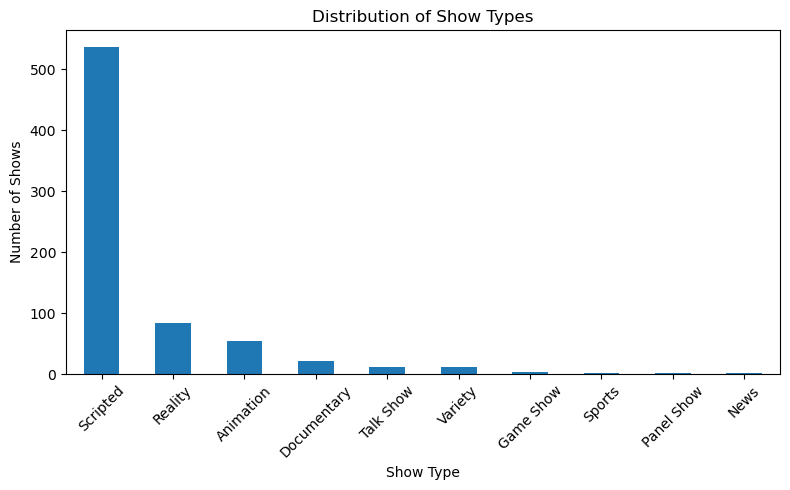

In [272]:
plt.figure(figsize=(8, 5))
show_type_counts.plot(kind="bar")
plt.title("Distribution of Show Types")
plt.xlabel("Show Type")
plt.ylabel("Number of Shows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The majority of shows in the dataset are `Scripted`, while other show types such as Reality, Animation, Documentary, Talk Show, and News appear much less frequently. This suggests that the dataset is highly concentrated around scripted content, which may affect later analysis and recommendations.

## 7.2 Distribution of Languages

This analysis shows the most common languages in the dataset. It helps identify whether the catalog is diverse or concentrated around specific languages.

In [273]:
language_counts = df_cleaned["language"].value_counts()

language_counts

language
English     718
Japanese      8
Name: count, dtype: int64

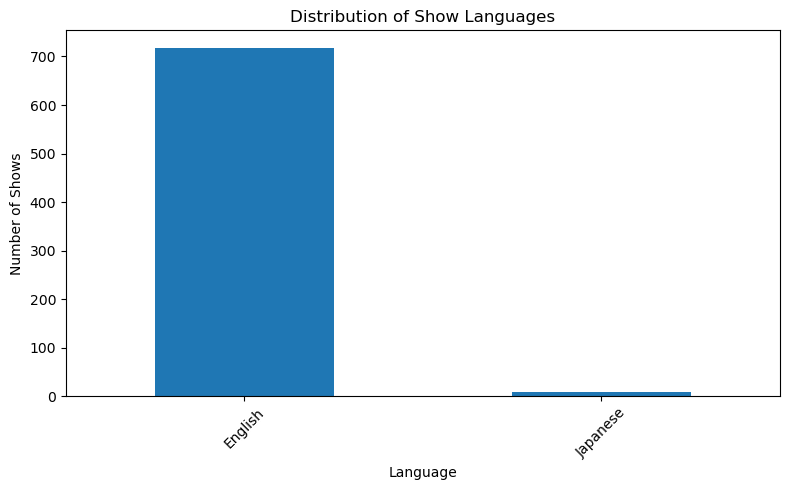

In [274]:
plt.figure(figsize=(8, 5))
language_counts.plot(kind="bar")
plt.title("Distribution of Show Languages")
plt.xlabel("Language")
plt.ylabel("Number of Shows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The dataset is highly concentrated around English-language shows, while Japanese-language shows appear only in a very small number. This indicates a strong language imbalance in the dataset.

This pattern is important because it may affect the analysis results. For example, recommendations based on this dataset may favor English content and may not fairly represent non-English content.

## 7.3 Most Common Genres

This analysis shows the most frequent genres in the dataset. Since each show can have multiple genres, the genres column needs to be split before counting each genre separately.

In [275]:
# Split genres and count each genre separately
genre_counts = (
    df_cleaned["genres"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

genre_counts

genres
Drama              358
Comedy             245
Action             146
Crime              134
Science-Fiction    111
Adventure           85
Thriller            67
Romance             65
Unknown             57
Family              49
Mystery             45
Fantasy             37
Supernatural        33
Horror              28
History             20
Medical             17
Legal               14
Food                14
Children            13
War                 13
Sports               9
Music                9
Anime                8
Espionage            8
Travel               7
Western              5
Nature               4
DIY                  2
Adult                1
Name: count, dtype: int64

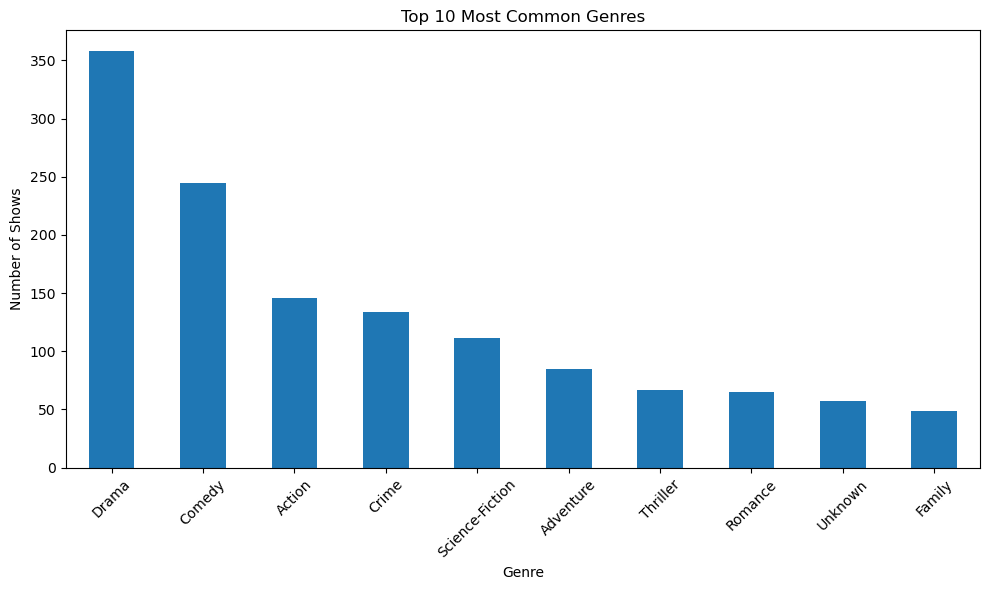

In [276]:
plt.figure(figsize=(10, 6))
genre_counts.head(10).plot(kind="bar")
plt.title("Top 10 Most Common Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Shows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Drama is the most common genre in the dataset, followed by Comedy, Action, Crime, and Science-Fiction. This shows that the catalog is strongly focused on scripted entertainment genres.

The presence of `Unknown` in the top genres indicates that some shows did not have genre information available in the original API data. This should be considered when making content strategy decisions, because missing genre data may affect the accuracy of genre-based recommendations.

## 7.4 Average Rating by Genre

This analysis calculates the average rating for each genre. Since each show can belong to multiple genres, the genres column will be split so each genre can be analyzed separately.

In [277]:
# Create a genre-level dataframe for rating analysis
genre_rating_df = df_cleaned.copy()

genre_rating_df["genres"] = genre_rating_df["genres"].str.split(",")
genre_rating_df = genre_rating_df.explode("genres")
genre_rating_df["genres"] = genre_rating_df["genres"].str.strip()

# Calculate average rating by genre
average_rating_by_genre = (
    genre_rating_df
    .groupby("genres")["rating_average"]
    .mean()
    .sort_values(ascending=False)
)

average_rating_by_genre

genres
Western            8.220000
Adult              8.100000
Espionage          7.900000
Medical            7.864706
DIY                7.850000
Crime              7.844030
Mystery            7.797778
War                7.792308
Adventure          7.721176
History            7.705000
Science-Fiction    7.696396
Drama              7.689106
Action             7.660959
Travel             7.657143
Anime              7.650000
Thriller           7.643284
Supernatural       7.627273
Legal              7.621429
Fantasy            7.572973
Horror             7.521429
Nature             7.425000
Food               7.385714
Family             7.361224
Comedy             7.355918
Sports             7.333333
Romance            7.301538
Unknown            7.175439
Children           6.523077
Music              6.300000
Name: rating_average, dtype: float64

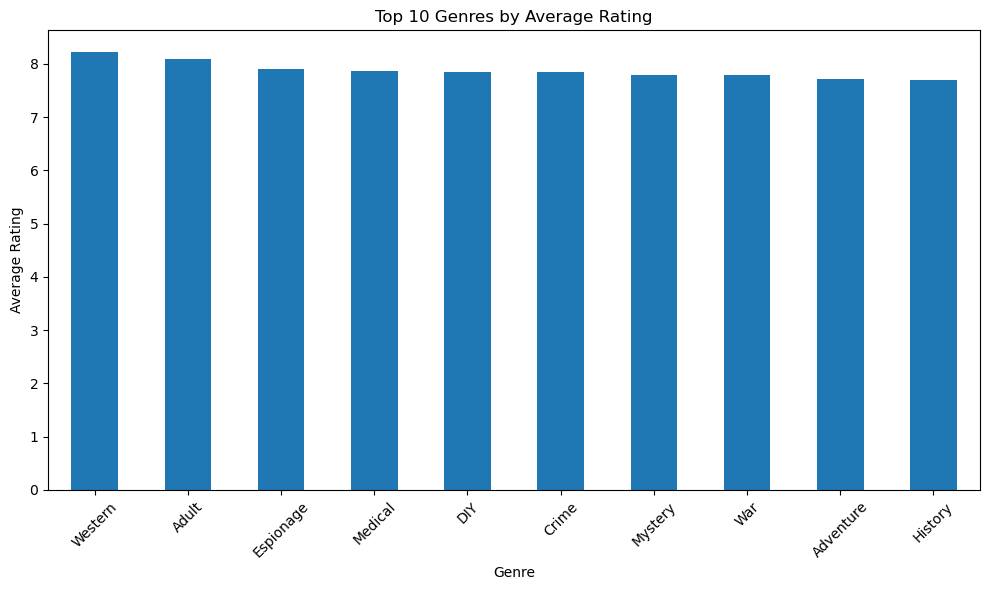

In [278]:
plt.figure(figsize=(10, 6))
average_rating_by_genre.head(10).plot(kind="bar")
plt.title("Top 10 Genres by Average Rating")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Western has the highest average rating, followed by Adult, Espionage, Medical, and DIY. However, some of these genres may have a small number of shows, so their average ratings should be interpreted carefully.

For more reliable recommendations, it is better to consider both average rating and genre availability. A genre with a high rating but very few shows may not be enough to make a strong business decision.

### Average Rating by Genre with Minimum Show Count

To make the rating comparison more reliable, I will filter the genres to include only genres with at least 10 shows. This helps reduce the effect of very small categories on the average rating.

In [279]:
genre_stats = (
    genre_rating_df
    .groupby("genres")
    .agg(
        average_rating=("rating_average", "mean"),
        show_count=("show_id", "count")
    )
    .sort_values(by="average_rating", ascending=False)
)

reliable_genre_stats = genre_stats[genre_stats["show_count"] >= 10]

reliable_genre_stats.head(10)

,average_rating,show_count
genres,,
Medical,7.864706,17
Crime,7.844030,134
Mystery,7.797778,45
War,7.792308,13
Adventure,7.721176,85
History,7.705000,20
Science-Fiction,7.696396,111
Drama,7.689106,358
Action,7.660959,146


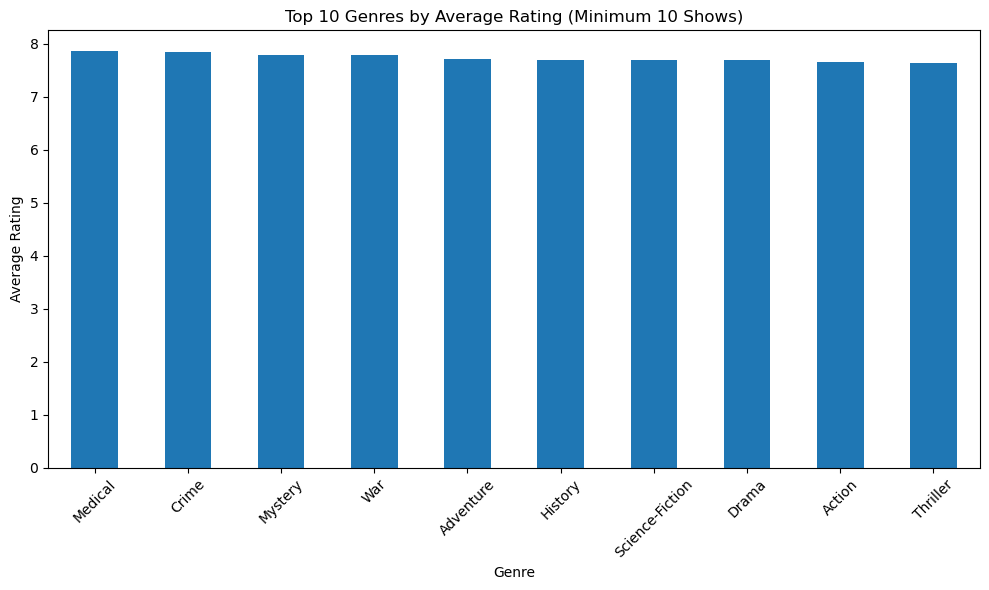

In [280]:
plt.figure(figsize=(10, 6))
reliable_genre_stats["average_rating"].head(10).plot(kind="bar")
plt.title("Top 10 Genres by Average Rating (Minimum 10 Shows)")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

After filtering genres to include only those with at least 10 shows, Medical, Crime, Mystery, War, and Adventure appear among the highest-rated genres. This makes the comparison more reliable because it avoids making decisions based on genres with very few shows.

Although Drama and Action are among the most common genres, some less frequent genres such as Medical and Mystery have slightly higher average ratings. This suggests that the platform should not only focus on the most available genres, but also consider genres with strong average ratings when planning content acquisition.

## 7.5 Relationship Between Runtime and Rating

This analysis explores whether there is a relationship between show runtime and average rating. This can help understand if longer or shorter shows tend to receive higher ratings.

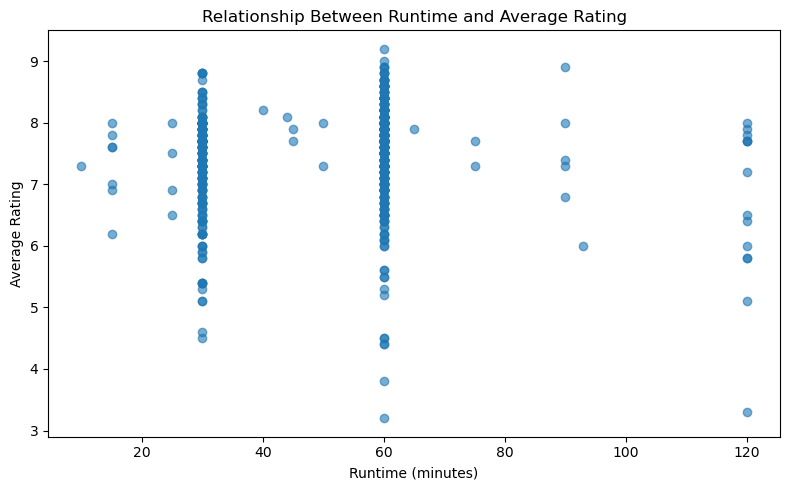

In [281]:
plt.figure(figsize=(8, 5))
plt.scatter(df_cleaned["runtime"], df_cleaned["rating_average"], alpha=0.6)
plt.title("Relationship Between Runtime and Average Rating")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

In [282]:
runtime_rating_corr = df_cleaned["runtime"].corr(df_cleaned["rating_average"])

print("Correlation between runtime and average rating:", round(runtime_rating_corr, 3))

Correlation between runtime and average rating: 0.031


### Insight

The correlation between runtime and average rating is 0.031, which indicates a very weak relationship. This means that show runtime does not appear to have a strong impact on average rating in this dataset.

For the streaming platform, this suggests that content decisions should not depend mainly on runtime. Other factors such as genre, language, network, and content type may be more useful for content strategy decisions.

## 7.6 Show Production Trends Over Time

This analysis shows how the number of premiered shows changed over time. It helps identify content release trends and whether the catalog is concentrated in specific years.

In [283]:
shows_by_year = df_cleaned["premiere_year"].value_counts().sort_index()

shows_by_year.tail(20)

premiere_year
1996      6
1997     11
1998      7
1999     13
2000     10
2001     13
2002     13
2003     19
2004     22
2005     26
2006     18
2007     20
2008     18
2009     34
2010     43
2011     64
2012     67
2013     84
2014    157
2015     29
Name: count, dtype: int64

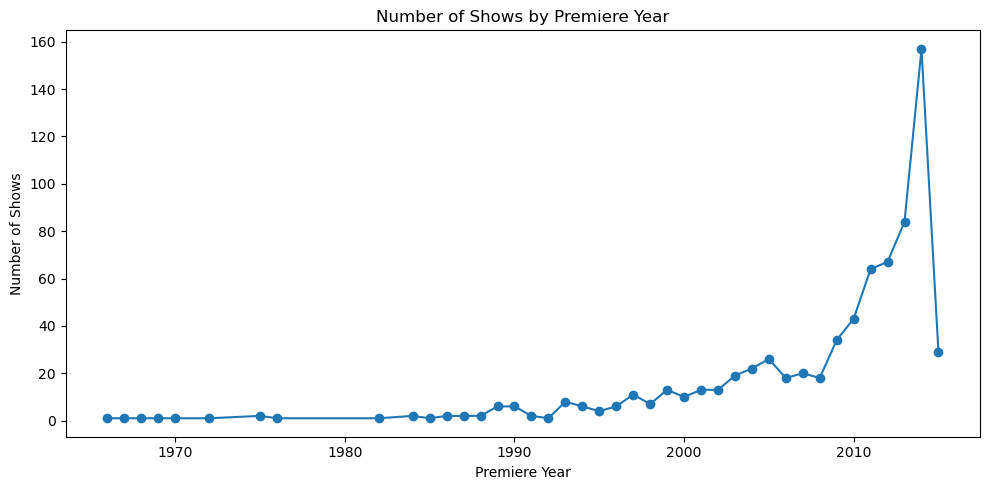

In [284]:
plt.figure(figsize=(10, 5))
shows_by_year.plot(kind="line", marker="o")
plt.title("Number of Shows by Premiere Year")
plt.xlabel("Premiere Year")
plt.ylabel("Number of Shows")
plt.tight_layout()
plt.show()

### Insight

The number of premiered shows increased gradually over time, especially after the early 2000s. The dataset shows a strong peak around 2014, which suggests that many shows in this sample premiered during that period.

The drop after the peak may not necessarily mean that TV show production decreased overall. It may be related to how the API data was collected, the selected pages, or the availability of records in the dataset. Therefore, this trend should be interpreted carefully.

## 7.7 Top Networks by Number of Shows

This analysis identifies the networks with the highest number of shows in the dataset. It helps understand which networks contribute the most content to the catalog.

In [285]:
network_counts = df_cleaned["network_name"].value_counts().head(10)

network_counts

network_name
NBC            66
ABC            59
CBS            53
FOX            48
Unknown        39
HBO            30
Syfy           24
The CW         23
BBC One        21
USA Network    20
Name: count, dtype: int64

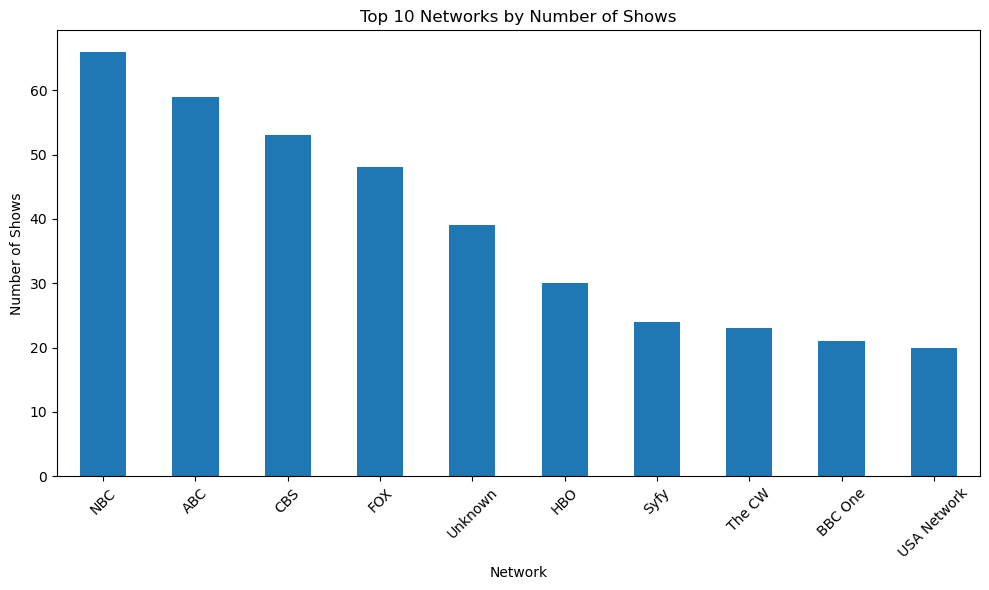

In [286]:
plt.figure(figsize=(10, 6))
network_counts.plot(kind="bar")
plt.title("Top 10 Networks by Number of Shows")
plt.xlabel("Network")
plt.ylabel("Number of Shows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

NBC, ABC, CBS, FOX, and HBO are the top networks by number of shows in the dataset. This suggests that the dataset is strongly represented by major TV networks, especially large U.S. networks.

The presence of `Unknown` among the top values shows that some records did not include network information in the original API data. This missing network information should be considered when analyzing network-level performance or making content acquisition decisions.

## 7.8 Rating Category Distribution

This analysis shows how shows are distributed across Low, Medium, and High rating categories. It helps understand the overall quality level of the catalog based on average ratings.

In [287]:
rating_category_counts = df_cleaned["rating_category"].value_counts()

rating_category_counts

rating_category
High      576
Medium    141
Low         9
Name: count, dtype: int64

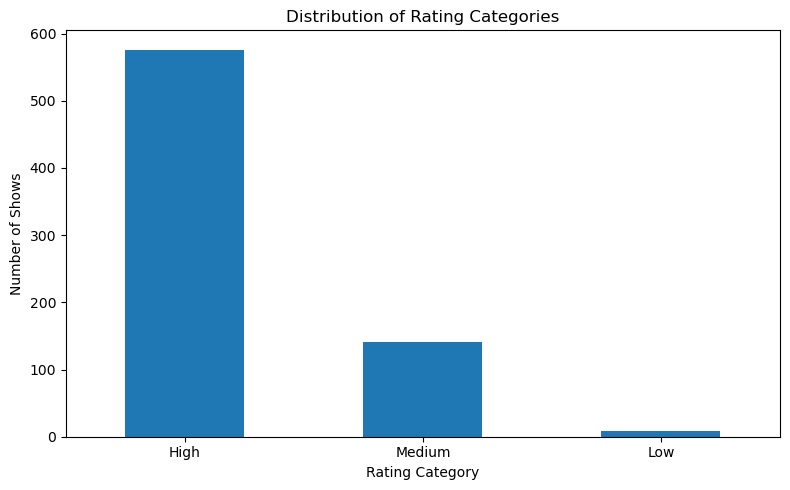

In [288]:
plt.figure(figsize=(8, 5))
rating_category_counts.plot(kind="bar")
plt.title("Distribution of Rating Categories")
plt.xlabel("Rating Category")
plt.ylabel("Number of Shows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

Most shows in the dataset fall under the `High` rating category, while fewer shows are classified as `Medium`, and only a small number are classified as `Low`. This suggests that the catalog is generally concentrated around highly rated shows.

However, this result should be interpreted carefully because missing ratings were filled using the median. This may increase the number of shows in the higher or middle rating categories and may affect the true distribution of ratings.

## 7.9 Distribution of Episode Count Categories

This analysis shows how shows are distributed across episode count categories. It helps understand whether the catalog is dominated by short or long-running shows, which can support content acquisition decisions.

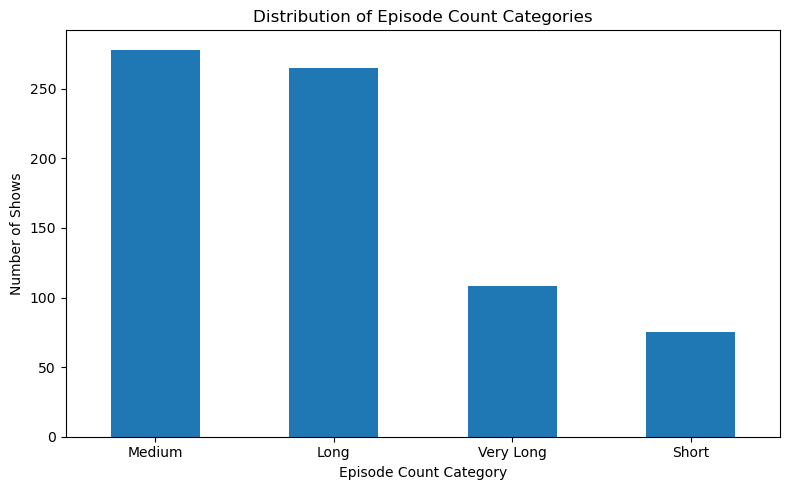

In [289]:
episode_category_counts = df_cleaned["episode_count_category"].value_counts()

plt.figure(figsize=(8, 5))
episode_category_counts.plot(kind="bar")
plt.title("Distribution of Episode Count Categories")
plt.xlabel("Episode Count Category")
plt.ylabel("Number of Shows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

Medium and Long shows are the most common in the dataset, while Short and Very Long shows appear less frequently. This suggests that the catalog is mainly concentrated around shows with moderate to high episode counts.

For the streaming platform, this may indicate stronger content continuity and better potential for longer viewer engagement.

# 8. Bias and Fairness Evaluation

Bias and fairness are important in data analysis because the dataset may not represent all groups equally. If the dataset is biased, the insights and recommendations may also become biased.

## Common Sources of Data Bias

Common sources of data bias include:

- Representation bias: when some groups are overrepresented or underrepresented in the dataset.
- Measurement bias: when data values are collected or measured in a way that is not equally accurate for all groups.
- Historical bias: when the dataset reflects existing historical patterns or inequalities.
- Missing data bias: when missing values are not random and affect certain groups more than others.

## Existing Frameworks for Bias Evaluation

Some existing frameworks and guidelines used to evaluate bias include:

- IBM AI Fairness 360: an open-source toolkit for detecting and mitigating bias in datasets and machine learning models.
- Google What-If Tool: a visual tool for exploring model behavior and fairness across different groups.
- General fairness guidelines that recommend comparing results across important groups before making decisions.

## Dataset Bias Evaluation

### Representation Bias

The dataset is strongly concentrated around English-language shows and Scripted content. This means that non-English shows and other show types, such as Reality, Documentary, Talk Show, and News, are underrepresented.

This may cause the final insights to favor English scripted content more than other types of shows.

### Measurement Bias

Some columns had missing values, especially `official_site`, `rating_average`, `network_name`, and `genres`. Ratings may also not be available for all shows equally. This can affect comparisons between genres, networks, or content types.

### Historical Bias

The dataset reflects the shows available in the TVMaze API and the selected pages collected from the API. Since older shows and certain networks may be represented differently, the dataset may reflect historical availability patterns rather than the full TV market.

## Impact on Results

These biases may affect the analysis and recommendations. For example, the platform may appear to benefit more from investing in English scripted shows because these shows are highly represented in the dataset. However, this does not necessarily mean that non-English or less common content types are less valuable.

## Recommendations to Mitigate Bias

To reduce bias in future analysis, the following steps are recommended:

- Collect more data from additional TVMaze API pages or endpoints.
- Include more non-English shows and international content.
- Compare results across different languages, countries, and content types.
- Avoid making recommendations based only on categories with very small sample sizes.
- Clearly document missing data and avoid over-interpreting incomplete fields.

# 9. Saving the Final Cleaned Dataset

After completing data cleaning and feature engineering, the final cleaned dataset will be saved as a CSV file. This file will be used for future analysis, visualization, and reporting.

In [291]:
import os

# Create cleaned data folder if it does not exist
os.makedirs("data/cleaned", exist_ok=True)

# Save the cleaned and feature-engineered dataset
df_cleaned.to_csv("data/cleaned/shows_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print("File path: data/cleaned/shows_cleaned.csv")
print("Final cleaned dataset shape:", df_cleaned.shape)

Cleaned dataset saved successfully.
File path: data/cleaned/shows_cleaned.csv
Final cleaned dataset shape: (726, 36)


# 10. Step 2 Summary

In Step 2, I processed and explored the cleaned TV show dataset. The main work included data inspection, data cleaning, feature engineering, exploratory data analysis, and bias and fairness evaluation.

## Data Cleaning Summary

The dataset was checked for missing values, duplicate rows, inconsistent values, and data type issues. No duplicate rows were found.

Missing categorical values were filled with `Unknown`, missing official website values were filled with `Not Available`, and missing numerical values were filled using the median. The `premiered` and `ended` columns were converted into datetime format.

Rows with missing premiere dates were removed because the premiere date is important for time-based analysis. Missing values in the `ended` column were kept because they may indicate that the show is still running.

The `summary` column was cleaned by removing HTML tags to make the text more readable and useful for text-based feature engineering.

## Feature Engineering Summary

Several new features were created to improve the dataset and support deeper analysis:

| Feature | Purpose |
|---|---|
| `premiere_year` | Extracted from the premiere date to analyze release trends over time |
| `premiere_month` | Extracted from the premiere date to support time-based analysis |
| `is_ended` | Identifies whether a show has an end date or may still be running |
| `show_age` | Calculates how many years have passed since the show premiered |
| `genre_count` | Counts how many genres are assigned to each show |
| `summary_word_count` | Counts the number of words in each cleaned show summary |
| `summary_character_count` | Counts the number of characters in each cleaned show summary |
| `summary_keywords` | Extracts the most frequent meaningful words from each cleaned show summary |
| `sentence_count` | Counts the number of sentences in each cleaned show summary |
| `average_sentence_length` | Measures the average number of words per sentence |
| `average_word_length` | Measures the average word length in each show summary |
| `sentiment_score` | Calculates the sentiment polarity of each cleaned show summary using TextBlob |
| `sentiment_label` | Classifies each summary as Positive, Neutral, or Negative |
| `summary_topic` | Groups show summaries into general text-based themes using topic modeling |
| `rating_category` | Groups shows into Low, Medium, and High rating categories |
| `content_cluster` | Groups shows based on selected numerical features using KMeans clustering |
| `episode_count` | Collects the number of episodes for each show from the TVMaze Episodes API |
| `episode_count_category` | Groups shows into Short, Medium, Long, and Very Long categories based on episode count |
| `pca_component_1` | First PCA component created from selected standardized numerical features |
| `pca_component_2` | Second PCA component created from selected standardized numerical features |

## EDA Summary

The exploratory data analysis showed several initial patterns:

- Most shows in the dataset are `Scripted`.
- The dataset is highly concentrated around English-language shows.
- Drama, Comedy, Action, Crime, and Science-Fiction are among the most common genres.
- After filtering genres to include only those with at least 10 shows, Medical, Crime, Mystery, War, and Adventure appear among the highest-rated genres.
- Runtime has a very weak relationship with average rating.
- The number of premiered shows increased over time, with a noticeable peak around 2014.
- NBC, ABC, CBS, FOX, and HBO are among the top networks by number of shows.
- Most shows fall under the `High` rating category.
- Medium and Long shows are the most common episode count categories in the dataset.

## Bias and Fairness Summary

The dataset may contain representation bias because English-language shows and Scripted content are strongly represented, while non-English shows and other content types are underrepresented.

Measurement bias may also exist because some fields, such as ratings, genres, networks, and official websites, had missing values. Filling missing numerical values using the median helped keep the dataset usable, but it may also affect the true distribution of ratings.

Historical bias may be present because the dataset reflects the shows available in the TVMaze API and the selected pages collected. This may not fully represent the complete TV market.

These limitations should be considered when using the results to make content strategy recommendations.